# Refocus Data Analyst Final Project Set 1

**Data Analyst Goals**

**Question 1**
Create a scatter plot of state income vs. corruption convictions per capita.

**Question 2**
Test whether state income and corruption convictions per capita are correlated. Use the df.corr() method for this task.

**Question 3**
Create a histogram of the income distribution for all states.

# Pre-Work

**Import Data from Google Drive**

In [1]:
# Import Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Import Libraries**

In [2]:
# Import Libraries (Complete)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime

# Hypothesis Testing - Means
from scipy.stats import ttest_1samp
from scipy.stats import ttest_ind
from scipy.stats import ttest_rel

# Hypothesis Testing - Proportions
from statsmodels.stats.proportion import binom_test
from scipy.stats import chisquare

%matplotlib inline

# Question 1

Create a scatter plot of state income vs. corruption convictions per capita.

In [3]:
# Read CSV file - tb_summary_income_convictions.csv
df_income_convictions = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Refocus_Modules/FP_set1/tb_summary_income_convictions.csv')

In [4]:
# Head - df_income_convictions
df_income_convictions.head()

,state_usa,sum_avg_income,percent_income_usa,sum_convictions,percent_convictions
0,Maryland,89392,2.831276,1.38,1.628703
1,Massachusetts,82427,2.610677,2.27,2.679098
2,New Jersey,81740,2.588918,1.90,2.242417
3,California,80440,2.547743,1.09,1.286439
4,Connecticut,79287,2.511225,2.01,2.372241


In [5]:
# Create a copy dataframe (df_income_convictions2) but drop columns - percent_income_usa & percent_convictions

df_income_convictions2 = df_income_convictions.drop(['percent_income_usa', 'percent_convictions'], axis=1)
df_income_convictions2.head()

,state_usa,sum_avg_income,sum_convictions
0,Maryland,89392,1.38
1,Massachusetts,82427,2.27
2,New Jersey,81740,1.90
3,California,80440,1.09
4,Connecticut,79287,2.01


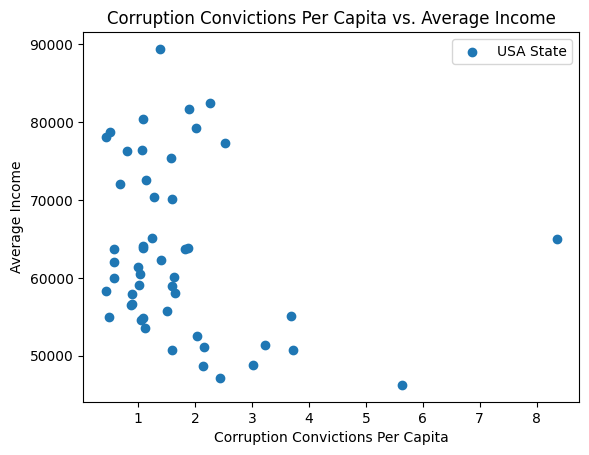

In [6]:
# Create a scatter plot from df_income_convictions2

plt.scatter(
    x=df_income_convictions2['sum_convictions'],
    y=df_income_convictions2['sum_avg_income'])

plt.title('Corruption Convictions Per Capita vs. Average Income')
plt.xlabel('Corruption Convictions Per Capita')
plt.ylabel('Average Income')
plt.legend(['USA State'], loc="upper right")

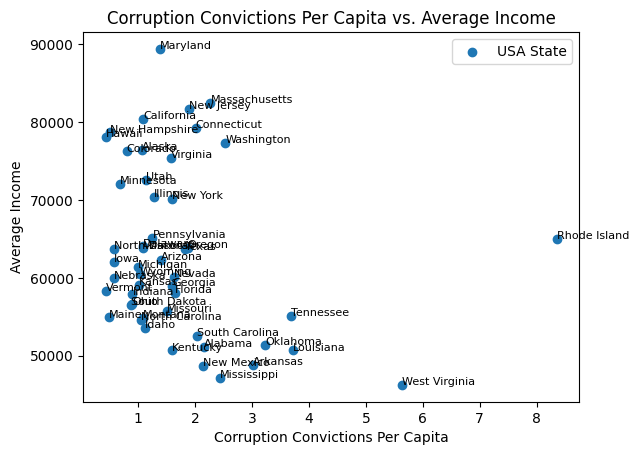

In [7]:
# Create a scatter plot from df_income_convictions2 + Annotation (USA State)

x=df_income_convictions2['sum_convictions']
y=df_income_convictions2['sum_avg_income']
n=df_income_convictions2['state_usa']

fig, ax = plt.subplots()
ax.scatter(x, y)

for i, txt in enumerate(n):
    ax.annotate(txt, (x[i], y[i]), fontsize=8)

plt.title('Corruption Convictions Per Capita vs. Average Income')
plt.xlabel('Corruption Convictions Per Capita')
plt.ylabel('Average Income')
plt.legend(['USA State'], loc="upper right")

# Question 2

Test whether state income and corruption convictions per capita are correlated. Use the df.corr() method for this task.

In [8]:
# Correlation Matrix
df_income_convictions2.corr()

<ipython-input-8-350f0b22efed>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_income_convictions2.corr()


,sum_avg_income,sum_convictions
sum_avg_income,1.000000,-0.226282
sum_convictions,-0.226282,1.000000


<ipython-input-9-08f699c905c7>:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df_income_convictions2.corr(), annot=True, cmap="RdYlGn", vmin=-1, vmax=1)


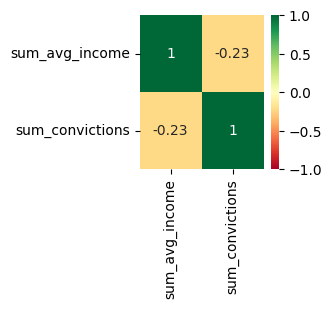

In [9]:
# Heatmap / df_income_convictions2.corr()
plt.figure(figsize=(2,2))
sns.heatmap(df_income_convictions2.corr(), annot=True, cmap="RdYlGn", vmin=-1, vmax=1)
plt.show();

# Question 3

Create a histogram of the income distribution for all states.

Text(0, 0.5, 'Count of State')

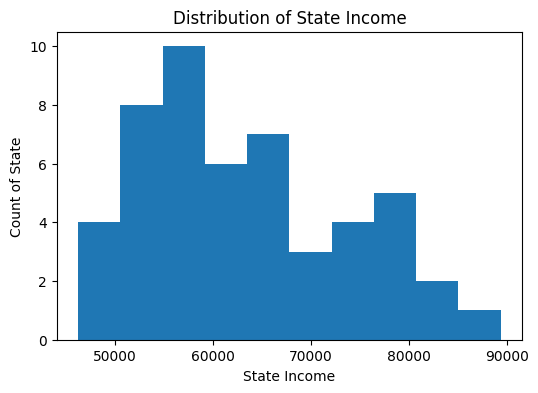

In [10]:
# Histogram, plt.subplots, .plot(kind='hist')

fig, ax = plt.subplots(figsize=(6, 4))
df_income_convictions['sum_avg_income'].plot(kind='hist', ax=ax)
ax.set_title('Distribution of State Income')
ax.set_xlabel('State Income')
ax.set_ylabel('Count of State')

# Additional Tasks

**NOTE:**
Other Additional Tasks in the documentation is not required to be processed in Python, thus you will not see below items in sequential order or you might see that some items are skipped, these are processed either in Excel, SQL, or Power BI.

**Q2. Create a heat map showing the relationship between population density and property prices.**

In [11]:
# Read CSV
df_population_propertyprices = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Refocus_Modules/FP_set1/tb_population_propertyprices.csv')

# Head
print(df_population_propertyprices.head())

# Drop columns not needed
df_population_propertyprices2 = df_population_propertyprices.drop(['min_price', 'max_price'], axis=1)
print(df_population_propertyprices2.head())

    state_usa  estimate  avg_price  min_price  max_price
0     Alabama   4903185    1797.50     1200.0     2500.0
1      Alaska    731545    2684.00     2000.0     3500.0
2     Arizona   7278717    2356.75     1500.0     4000.0
3    Arkansas   3017804    1499.25     1000.0     2500.0
4  California  39512223    5832.50     3500.0     9000.0
    state_usa  estimate  avg_price
0     Alabama   4903185    1797.50
1      Alaska    731545    2684.00
2     Arizona   7278717    2356.75
3    Arkansas   3017804    1499.25
4  California  39512223    5832.50


In [12]:
# Correlation Matrix - Population & Property Prices
df_population_propertyprices2.corr()

<ipython-input-12-34d24c868f79>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_population_propertyprices2.corr()


,estimate,avg_price
estimate,1.000000,0.418059
avg_price,0.418059,1.000000


<ipython-input-13-8346de142d2a>:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df_population_propertyprices2.corr(), annot=True, cmap="RdYlGn", vmin=-1, vmax=1)


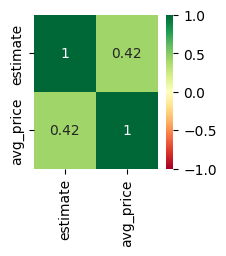

In [13]:
# Heatmap / df_population_propertyprices2.corr()
plt.figure(figsize=(2,2))
sns.heatmap(df_population_propertyprices2.corr(), annot=True, cmap="RdYlGn", vmin=-1, vmax=1)
plt.show();

**Q6. Create a scatterplot that shows the correlation between property prices and state income.**

In [14]:
# Read CSV
df_propertyprice_stateincome = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Refocus_Modules/FP_set1/tb_propertyprice_stateincome.csv')

# Head
print(df_propertyprice_stateincome.head())

    state_usa  avg_price  average_income
0     Alabama    1797.50           51113
1      Alaska    2684.00           76440
2     Arizona    2356.75           62283
3    Arkansas    1499.25           48829
4  California    5832.50           80440


In [15]:
# Correlation Matrix - Property Prices & State Income
df_propertyprice_stateincome.corr()

<ipython-input-15-210c8bb21bb5>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_propertyprice_stateincome.corr()


,avg_price,average_income
avg_price,1.000000,0.739453
average_income,0.739453,1.000000


<ipython-input-16-4a9a860f20df>:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df_propertyprice_stateincome.corr(), annot=True, cmap="RdYlGn", vmin=-1, vmax=1)


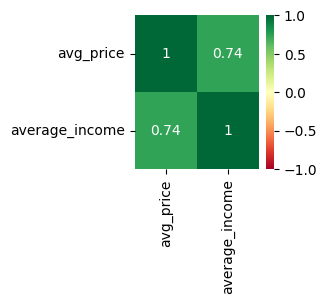

In [16]:
# Heatmap / df_propertyprice_stateincome.corr()
plt.figure(figsize=(2,2))
sns.heatmap(df_propertyprice_stateincome.corr(), annot=True, cmap="RdYlGn", vmin=-1, vmax=1)
plt.show();

**Q8. Use Python to calculate the average, minimum, and maximum corruption levels for different regions of the country.**

In [17]:
# Read CSV
df_corruption_region = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Refocus_Modules/FP_set1/tb_corruption_region.csv')

# Head
df_corruption_region.head()

,state_usa,convictions_per_capita,state,state_code,region,division
0,Alabama,2.15,Alabama,AL,South,East South Central
1,Alaska,1.06,Alaska,AK,West,Pacific
2,Arizona,1.40,Arizona,AZ,West,Mountain
3,Arkansas,3.02,Arkansas,AR,South,West South Central
4,California,1.09,California,CA,West,Pacific


In [18]:
# Group by Region - Avg
df_corruption_region_avg = df_corruption_region.groupby('region')[['convictions_per_capita']].mean()
df_corruption_region_avg

,convictions_per_capita
region,
Midwest,0.911667
Northeast,2.088889
South,2.354375
West,1.332308


In [19]:
# Group by Region - Min
df_corruption_region_min = df_corruption_region.groupby('region')[['convictions_per_capita']].min()
df_corruption_region_min

,convictions_per_capita
region,
Midwest,0.57
Northeast,0.44
South,1.05
West,0.43


In [20]:
# Group by Region - Max
df_corruption_region_max = df_corruption_region.groupby('region')[['convictions_per_capita']].max()
df_corruption_region_max

,convictions_per_capita
region,
Midwest,1.50
Northeast,8.35
South,5.64
West,2.53


**Q11. Use SQL to calculate the total healthcare spending for each state and compare the results to the state's population.**

In [21]:
# Read CSV
df_spending_population = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Refocus_Modules/FP_set1/tb_spending_population.csv')

# Head
df_spending_population.head()

,state_usa,avg_spending,estimate
0,Alabama,200.50,4903185
1,Alaska,300.25,731545
2,Arizona,150.00,7278717
3,Arkansas,175.00,3017804
4,California,250.75,39512223


In [22]:
# Correlation Matrix
df_spending_population.corr()

<ipython-input-22-7ba7455dd905>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_spending_population.corr()


,avg_spending,estimate
avg_spending,1.000000,0.139162
estimate,0.139162,1.000000


<ipython-input-23-782b23b7a524>:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df_spending_population.corr(), annot=True, cmap="RdYlGn", vmin=-1, vmax=1)


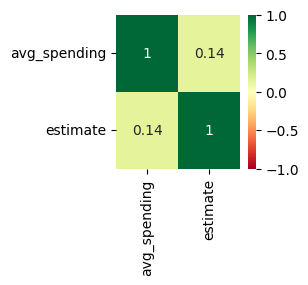

In [23]:
# Heatmap / df_spending_population.corr()
plt.figure(figsize=(2,2))
sns.heatmap(df_spending_population.corr(), annot=True, cmap="RdYlGn", vmin=-1, vmax=1)
plt.show();

**Q13. Use Python to calculate the average corruption level for states with different population densities and compare the results.**

In [24]:
# Read CSV
df_corruption = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Refocus_Modules/FP_set1/corruption_convictions_per_capita.csv')

# Head
df_corruption.head()

,state_usa,convictions_per_capita
0,Alabama,2.15
1,Alaska,1.06
2,Arizona,1.40
3,Arkansas,3.02
4,California,1.09


In [25]:
# Read CSV
df_population = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Refocus_Modules/FP_set1/population.csv')

# Head
df_population.head()

,state_usa,estimate
0,Alabama,4903185
1,Alaska,731545
2,Arizona,7278717
3,Arkansas,3017804
4,California,39512223


In [26]:
# Join the two dataframes above
df_corruption_population = pd.merge(df_corruption, df_population, on="state_usa", how='inner')

# Display df_corruption_population
df_corruption_population

,state_usa,convictions_per_capita,estimate
0,Alabama,2.15,4903185
1,Alaska,1.06,731545
2,Arizona,1.40,7278717
3,Arkansas,3.02,3017804
4,California,1.09,39512223
5,Colorado,0.80,5758736
6,Connecticut,2.01,3565287
7,Delaware,1.08,973764
8,Florida,1.65,21477737
9,Georgia,1.60,10617423


In [27]:
# Correlation Matrix
df_corruption_population.corr()

<ipython-input-27-5f488ae9f53a>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_corruption_population.corr()


,convictions_per_capita,estimate
convictions_per_capita,1.000000,-0.073595
estimate,-0.073595,1.000000


<ipython-input-28-dc29fcc2aef2>:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df_corruption_population.corr(), annot=True, cmap="RdYlGn", vmin=-1, vmax=1)


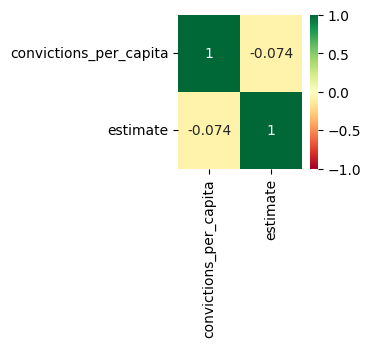

In [28]:
# Heatmap / df_corruption_population.corr()
plt.figure(figsize=(2,2))
sns.heatmap(df_corruption_population.corr(), annot=True, cmap="RdYlGn", vmin=-1, vmax=1)
plt.show();

**Q15. Use SQL to calculate the total profit for competitors in each state and compare the results to the state's population.**

In [29]:
# Read CSV
df_agg_compet_popul = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Refocus_Modules/FP_set1/tb_agg_competitors_population.csv')

# Head
df_agg_compet_popul.head()

,state_usa,sum_profit,sum_estimate_population
0,Alabama,5692296.95,24515925
1,Alaska,9845632.95,3657725
2,Arizona,2942282.99,7278717
3,Arkansas,1487917.98,6035608
4,California,10754524.00,1066830021


In [30]:
# Correlation Matrix
df_agg_compet_popul.corr()

<ipython-input-30-10e55f963a5c>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_agg_compet_popul.corr()


,sum_profit,sum_estimate_population
sum_profit,1.000000,0.107887
sum_estimate_population,0.107887,1.000000


<ipython-input-31-ca6ec3a33ee9>:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df_agg_compet_popul.corr(), annot=True, cmap="RdYlGn", vmin=-1, vmax=1)


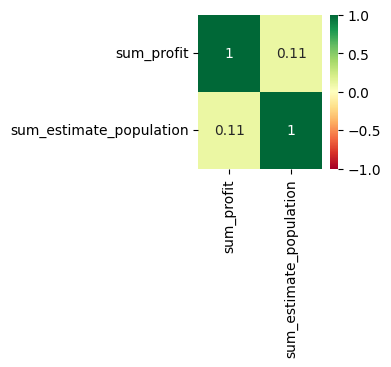

In [31]:
# Heatmap / df_agg_compet_popul.corr()
plt.figure(figsize=(2,2))
sns.heatmap(df_agg_compet_popul.corr(), annot=True, cmap="RdYlGn", vmin=-1, vmax=1)
plt.show();

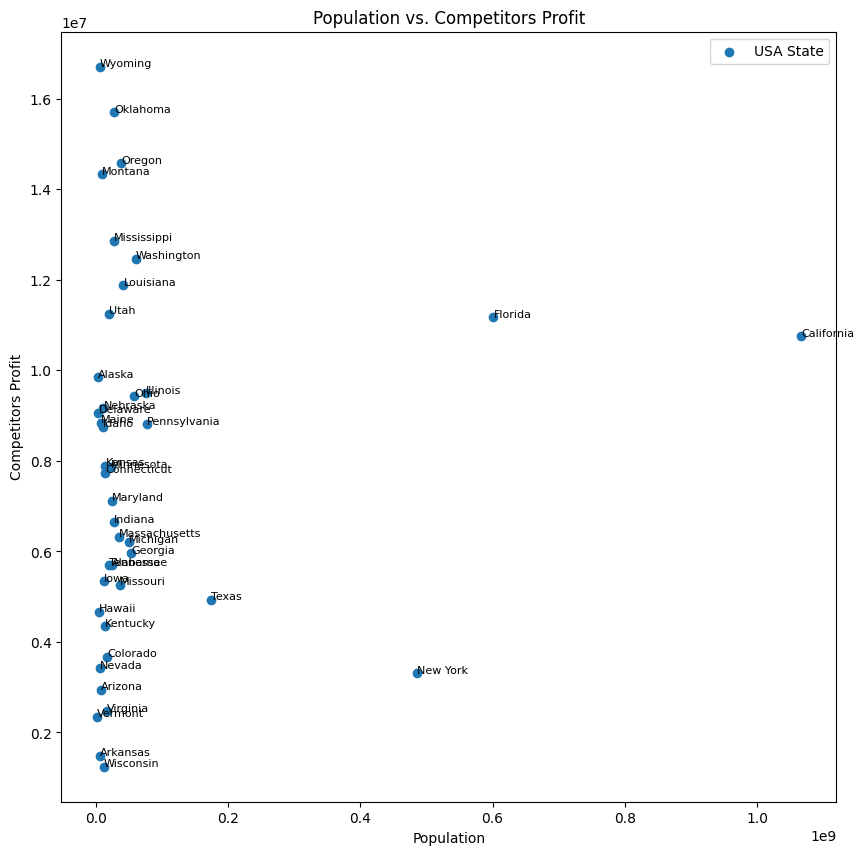

In [32]:
# Scatter Plot - Population vs. Competitors Profit
x=df_agg_compet_popul['sum_estimate_population']
y=df_agg_compet_popul['sum_profit']
n=df_agg_compet_popul['state_usa']
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(x, y)
for i, txt in enumerate(n):
    ax.annotate(txt, (x[i], y[i]), fontsize=8)
plt.title('Population vs. Competitors Profit')
plt.xlabel('Population')
plt.ylabel('Competitors Profit')
plt.legend(['USA State'], loc="upper right")

# Additional Questions

**NOTE:** Other Additional Questions in the documentation is not required to be processed in Python, thus you will not see below items in sequential order or you might see that some items are skipped, these are processed either in Excel, SQL, or Power BI.

**Q1. Is there a correlation between corruption levels and healthcare spending in different states?**

In [33]:
# Read CSV - corruption
df_corruption = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Refocus_Modules/FP_set1/corruption_convictions_per_capita.csv')

# Read CSV - health_spending
df_health_spending = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Refocus_Modules/FP_set1/health_spending.csv')

In [34]:
# Head
display(df_corruption.head())

# Head
display(df_health_spending.head())

,state_usa,convictions_per_capita
0,Alabama,2.15
1,Alaska,1.06
2,Arizona,1.40
3,Arkansas,3.02
4,California,1.09


,state_usa,avg_spending,min_spending,max_spending
0,Alabama,200.50,50.0,500.0
1,Alaska,300.25,100.0,750.0
2,Arizona,150.00,25.0,300.0
3,Arkansas,175.00,75.0,400.0
4,California,250.75,50.0,600.0


In [35]:
# Merge - Inner Join - df_corruption & df_health_spending
df_join_corruption_healthspend = pd.merge(df_corruption, df_health_spending, on="state_usa", how='inner')
df_join_corruption_healthspend.head()

,state_usa,convictions_per_capita,avg_spending,min_spending,max_spending
0,Alabama,2.15,200.50,50.0,500.0
1,Alaska,1.06,300.25,100.0,750.0
2,Arizona,1.40,150.00,25.0,300.0
3,Arkansas,3.02,175.00,75.0,400.0
4,California,1.09,250.75,50.0,600.0


In [36]:
# Drop Columns - df_join_corruption_healthspend
df_join_corruption_healthspend2 = df_join_corruption_healthspend.drop(['min_spending', 'max_spending'], axis=1)
df_join_corruption_healthspend2.head()

,state_usa,convictions_per_capita,avg_spending
0,Alabama,2.15,200.50
1,Alaska,1.06,300.25
2,Arizona,1.40,150.00
3,Arkansas,3.02,175.00
4,California,1.09,250.75


In [37]:
# Correlation Matrix
df_join_corruption_healthspend2.corr()

<ipython-input-37-6149fac996fd>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_join_corruption_healthspend2.corr()


,convictions_per_capita,avg_spending
convictions_per_capita,1.000000,0.173831
avg_spending,0.173831,1.000000


<ipython-input-38-801a18b74d64>:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df_join_corruption_healthspend2.corr(), annot=True, cmap="RdYlGn", vmin=-1, vmax=1)


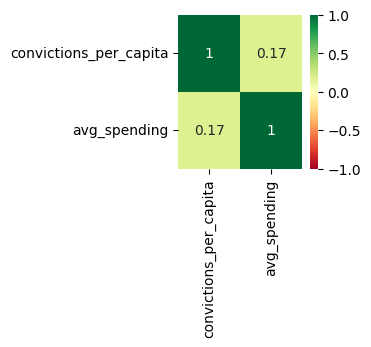

In [38]:
# Heatmap / df_join_corruption_healthspend2.corr()
plt.figure(figsize=(2,2))
sns.heatmap(df_join_corruption_healthspend2.corr(), annot=True, cmap="RdYlGn", vmin=-1, vmax=1)
plt.show();

**Q4. How does the level of corruption impact the profit of competitors in different states?**

In [39]:
# Read CSV - corruption
df_corruption = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Refocus_Modules/FP_set1/corruption_convictions_per_capita.csv')

# Read CSV - competitors
df_competitors = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Refocus_Modules/FP_set1/competitors.csv')

In [40]:
# Head
display(df_corruption.head())

# Head
display(df_competitors.head())

,state_usa,convictions_per_capita
0,Alabama,2.15
1,Alaska,1.06
2,Arizona,1.40
3,Arkansas,3.02
4,California,1.09


,research_development_spent,administration,marketing_spent,state_usa,profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [41]:
# Group By
df_group_competitors = df_competitors.groupby('state_usa')['profit'].sum().reset_index()
df_group_competitors.head()

,state_usa,profit
0,Alabama,5692296.95
1,Alaska,9845632.95
2,Arizona,2942282.99
3,Arkansas,1487917.98
4,California,10754524.00


In [42]:
# Merge - Inner Join - df_corruption & df_group_competitors
df_join_corruption_competitors = pd.merge(df_corruption, df_group_competitors, on="state_usa", how='inner')
df_join_corruption_competitors.head()

,state_usa,convictions_per_capita,profit
0,Alabama,2.15,5692296.95
1,Alaska,1.06,9845632.95
2,Arizona,1.40,2942282.99
3,Arkansas,3.02,1487917.98
4,California,1.09,10754524.00


In [43]:
# Correlation Matrix
df_join_corruption_competitors.corr()

<ipython-input-43-884de8bc1efd>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_join_corruption_competitors.corr()


,convictions_per_capita,profit
convictions_per_capita,1.000000,0.149096
profit,0.149096,1.000000


<ipython-input-44-9bb5d39fb930>:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df_join_corruption_competitors.corr(), annot=True, cmap="RdYlGn", vmin=-1, vmax=1)


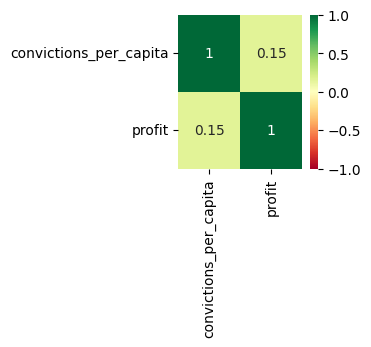

In [44]:
# Heatmap / df_join_corruption_competitors.corr()
plt.figure(figsize=(2,2))
sns.heatmap(df_join_corruption_competitors.corr(), annot=True, cmap="RdYlGn", vmin=-1, vmax=1)
plt.show();

**6. How does the population of a state impact its level of corruption?**

In [45]:
# Read CSV - corruption
df_corruption = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Refocus_Modules/FP_set1/corruption_convictions_per_capita.csv')

# Read CSV - population
df_population = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Refocus_Modules/FP_set1/population.csv')

In [46]:
# Head
display(df_corruption.head())

# Head
display(df_population.head())

,state_usa,convictions_per_capita
0,Alabama,2.15
1,Alaska,1.06
2,Arizona,1.40
3,Arkansas,3.02
4,California,1.09


,state_usa,estimate
0,Alabama,4903185
1,Alaska,731545
2,Arizona,7278717
3,Arkansas,3017804
4,California,39512223


In [47]:
# Merge - Inner Join - df_corruption & df_population
df_join_corruption_population = pd.merge(df_corruption, df_population, on="state_usa", how='inner')
df_join_corruption_population.head()

,state_usa,convictions_per_capita,estimate
0,Alabama,2.15,4903185
1,Alaska,1.06,731545
2,Arizona,1.40,7278717
3,Arkansas,3.02,3017804
4,California,1.09,39512223


In [48]:
# Correlation Matrix
df_join_corruption_population.corr()

<ipython-input-48-f0e63ba77d21>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_join_corruption_population.corr()


,convictions_per_capita,estimate
convictions_per_capita,1.000000,-0.073595
estimate,-0.073595,1.000000


<ipython-input-49-bb2f7aa60994>:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df_join_corruption_population.corr(), annot=True, cmap="RdYlGn", vmin=-1, vmax=1)


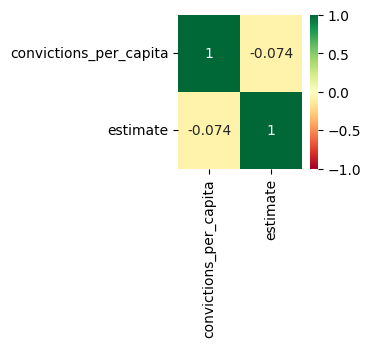

In [49]:
# Heatmap / df_join_corruption_population.corr()
plt.figure(figsize=(2,2))
sns.heatmap(df_join_corruption_population.corr(), annot=True, cmap="RdYlGn", vmin=-1, vmax=1)
plt.show();

**Q7. How does the level of healthcare spending vary between states, and which states spend the most/least per person?**

In [50]:
# Read CSV
df_health_spending = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Refocus_Modules/FP_set1/health_spending.csv')

# Head
df_health_spending.head()

,state_usa,avg_spending,min_spending,max_spending
0,Alabama,200.50,50.0,500.0
1,Alaska,300.25,100.0,750.0
2,Arizona,150.00,25.0,300.0
3,Arkansas,175.00,75.0,400.0
4,California,250.75,50.0,600.0


In [51]:
# Sort Values by avg_spending
df_health_spending_sorted = df_health_spending.sort_values(by='avg_spending', ascending=True)
df_health_spending_sorted.head()

,state_usa,avg_spending,min_spending,max_spending
49,Wyoming,125.5,50.0,300.0
11,Idaho,125.5,50.0,300.0
25,Montana,125.5,50.0,300.0
40,South Dakota,150.0,50.0,250.0
33,North Dakota,150.0,50.0,250.0


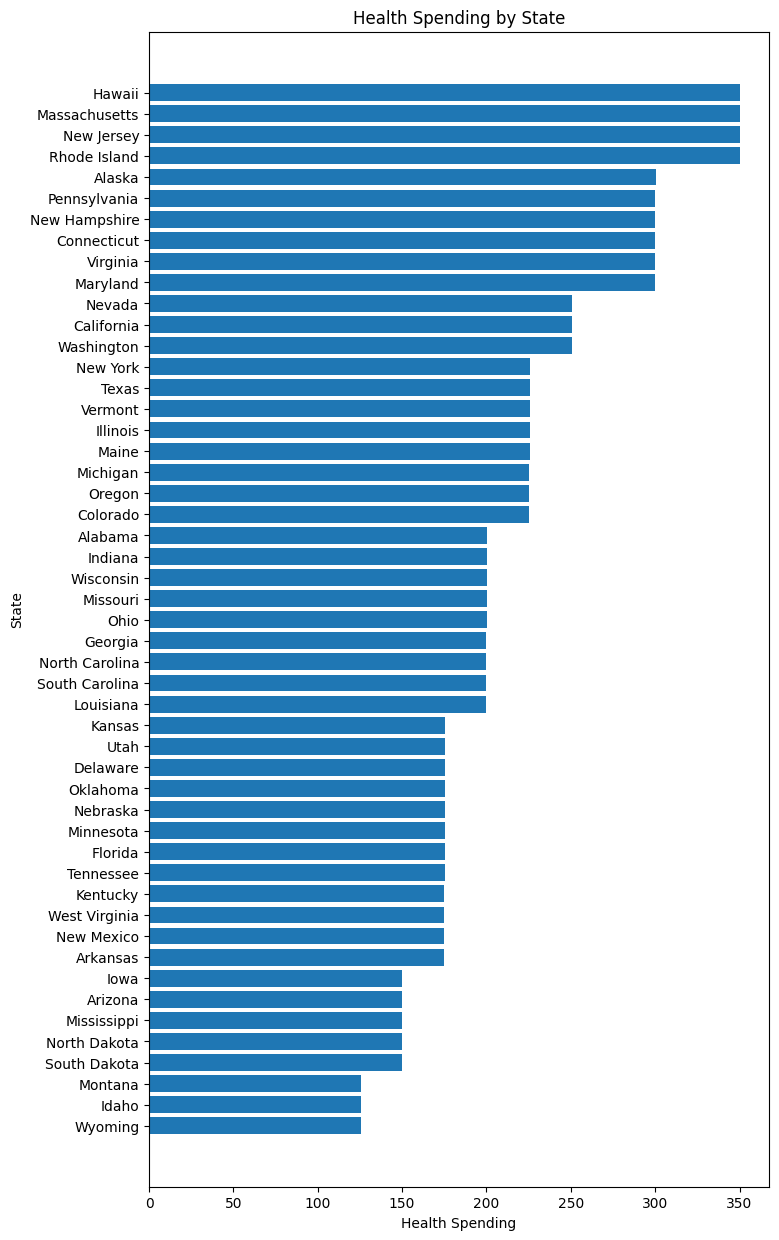

In [52]:
# Barh Plot
plt.figure(figsize=(8,15))
plt.barh(
    y=df_health_spending_sorted.state_usa,
    width=df_health_spending_sorted.avg_spending)
plt.title('Health Spending by State')
plt.ylabel('State')
plt.xlabel('Health Spending')
plt.show()

In [53]:
# Top 10 by min_spending
df_min_health_spending = df_health_spending[['state_usa', 'min_spending']].sort_values(by='min_spending', ascending=True).head(n=10)
df_min_health_spending

,state_usa,min_spending
2,Arizona,25.0
23,Mississippi,25.0
0,Alabama,50.0
46,Washington,50.0
43,Utah,50.0
41,Tennessee,50.0
40,South Dakota,50.0
35,Oklahoma,50.0
33,North Dakota,50.0
27,Nevada,50.0


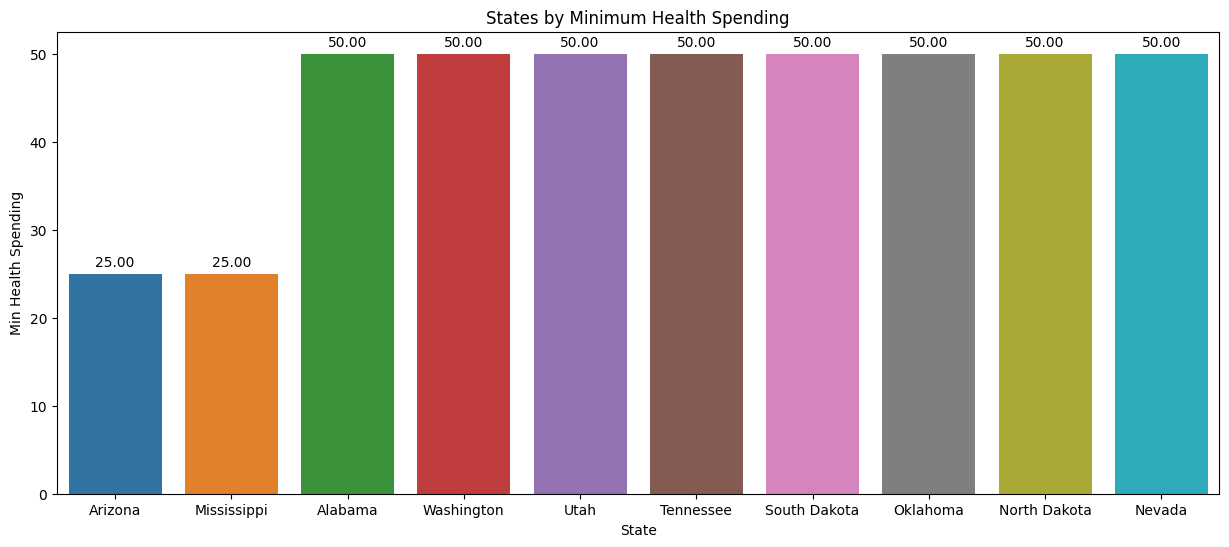

In [54]:
# Bar Plot - Min Health Spending
plt.figure(figsize=(15, 6))
plots = sns.barplot(x='state_usa', y='min_spending', data=df_min_health_spending)

for bar in plots.patches:
  plots.annotate(format(bar.get_height(), '.2f'),
                  (bar.get_x() + bar.get_width() / 2,
                  bar.get_height()), ha='center', va='center',
                  size=10, xytext=(0, 8),
                  textcoords='offset points')
plt.title('States by Minimum Health Spending')
plt.xlabel('State')
plt.ylabel('Min Health Spending')
plt.show()

In [55]:
# Top 10 by max_spending
df_max_health_spending = df_health_spending[['state_usa', 'max_spending']].sort_values(by='max_spending', ascending=False).head(n=10)
df_max_health_spending

,state_usa,max_spending
29,New Jersey,800.0
10,Hawaii,800.0
20,Massachusetts,800.0
38,Rhode Island,800.0
1,Alaska,750.0
37,Pennsylvania,700.0
6,Connecticut,700.0
19,Maryland,700.0
28,New Hampshire,700.0
45,Virginia,700.0


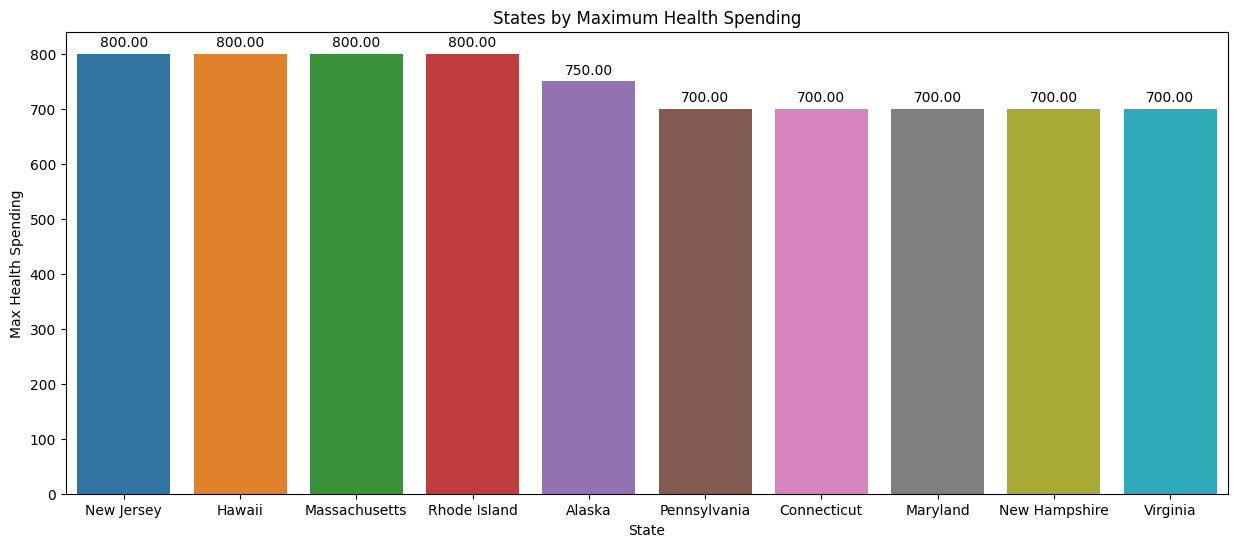

In [56]:
# Bar Plot - Max Health Spending
plt.figure(figsize=(15, 6))
plots = sns.barplot(x='state_usa', y='max_spending', data=df_max_health_spending)

for bar in plots.patches:
  plots.annotate(format(bar.get_height(), '.2f'),
                  (bar.get_x() + bar.get_width() / 2,
                  bar.get_height()), ha='center', va='center',
                  size=10, xytext=(0, 8),
                  textcoords='offset points')
plt.title('States by Maximum Health Spending')
plt.xlabel('State')
plt.ylabel('Max Health Spending')
plt.show()

**Q9. Which states have the highest and lowest minimum and maximum healthcare spending per person, and how do they compare to the national averages?**

In [57]:
# Read CSV
df_health_spending = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Refocus_Modules/FP_set1/health_spending.csv')

# Head
df_health_spending.head()

,state_usa,avg_spending,min_spending,max_spending
0,Alabama,200.50,50.0,500.0
1,Alaska,300.25,100.0,750.0
2,Arizona,150.00,25.0,300.0
3,Arkansas,175.00,75.0,400.0
4,California,250.75,50.0,600.0


In [58]:
# Describe to determine the mean
df_health_spending.describe()

,avg_spending,min_spending,max_spending
count,50.000000,50.000000,50.000000
mean,215.785000,87.000000,479.000000
std,61.786726,46.081117,159.747888
min,125.500000,25.000000,250.000000
25%,175.250000,50.000000,362.500000
50%,200.250000,75.000000,450.000000
75%,244.500000,100.000000,575.000000
max,350.000000,200.000000,800.000000


In [59]:
# States with Health Spending > 215.79
df_health_spending_gt_ave = df_health_spending[df_health_spending['avg_spending'] > 215.79]
df_health_spending_gt_ave[['state_usa', 'avg_spending']].sort_values(by='avg_spending', ascending=False)

,state_usa,avg_spending
10,Hawaii,350.00
38,Rhode Island,350.00
20,Massachusetts,350.00
29,New Jersey,350.00
1,Alaska,300.25
28,New Hampshire,300.00
45,Virginia,300.00
6,Connecticut,300.00
37,Pennsylvania,300.00
19,Maryland,300.00


In [60]:
# States with Health Spending < 215.79
df_health_spending_lt_ave = df_health_spending[df_health_spending['avg_spending'] < 215.79]
df_health_spending_lt_ave[['state_usa', 'avg_spending']].sort_values(by='avg_spending', ascending=False)

,state_usa,avg_spending
0,Alabama,200.50
13,Indiana,200.25
48,Wisconsin,200.25
34,Ohio,200.25
24,Missouri,200.25
9,Georgia,200.00
17,Louisiana,200.00
39,South Carolina,200.00
32,North Carolina,200.00
7,Delaware,175.50


**Q11. Are there any significant differences in corruption levels between states with high and low property prices, and how do they compare to the national average?**

In [61]:
# Read CSV - corruption
df_corruption = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Refocus_Modules/FP_set1/corruption_convictions_per_capita.csv')

# Read CSV - property_prices
df_property = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Refocus_Modules/FP_set1/property_prices.csv')

In [62]:
# Head
display(df_corruption.head())
display(df_property.head())

,state_usa,convictions_per_capita
0,Alabama,2.15
1,Alaska,1.06
2,Arizona,1.40
3,Arkansas,3.02
4,California,1.09


,state_usa,avg_price,min_price,max_price
0,Alabama,1797.50,1200.0,2500.0
1,Alaska,2684.00,2000.0,3500.0
2,Arizona,2356.75,1500.0,4000.0
3,Arkansas,1499.25,1000.0,2500.0
4,California,5832.50,3500.0,9000.0


In [63]:
# Describe property_prices
df_property.describe()

,avg_price,min_price,max_price
count,50.000000,50.000000,50.000000
mean,2412.035000,1592.000000,4280.000000
std,1107.501338,831.482571,4005.302608
min,1382.000000,800.000000,1000.000000
25%,1684.500000,1000.000000,2500.000000
50%,2056.500000,1200.000000,3500.000000
75%,2684.000000,1875.000000,4875.000000
max,5975.500000,4500.000000,30000.000000


mean_avg_price = 2412.035000

In [64]:
# Mean of avg_price
df_property_mean_avg_price = df_property['avg_price'].mean()
df_property_mean_avg_price

2412.035

In [65]:
# Quantile Data Frame of Property Price
df_quantile_property = df_property['avg_price'].quantile(q=[0.25, 0.5, 0.75])
df_quantile_property

0.25    1684.5
0.50    2056.5
0.75    2684.0
Name: avg_price, dtype: float64

In [66]:
# to_dict()
quantile_property = df_quantile_property.to_dict()
print(quantile_property[0.25])
print(quantile_property[0.5])
print(quantile_property[0.75])

1684.5
2056.5
2684.0


In [67]:
# Group by
df_group_property = df_property.groupby('state_usa')['avg_price'].mean().reset_index()
df_group_property.head()

,state_usa,avg_price
0,Alabama,1797.50
1,Alaska,2684.00
2,Arizona,2356.75
3,Arkansas,1499.25
4,California,5832.50


In [68]:
# Custom Function - add rating on avg_price
def rate(x):
    if x <= quantile_property[0.25]:
        return 'Low'
    elif x >= quantile_property[0.75]:
        return 'High'
    else:
        return 'Medium'

In [69]:
# Apply the custom function
df_group_property['rating'] = df_group_property['avg_price'].apply(rate)
df_group_property.head()

,state_usa,avg_price,rating
0,Alabama,1797.50,Medium
1,Alaska,2684.00,High
2,Arizona,2356.75,Medium
3,Arkansas,1499.25,Low
4,California,5832.50,High


In [70]:
# Merge - Inner Join - df_corruption & df_group_property
df_join_corruption_groupproperty = pd.merge(df_corruption, df_group_property, on="state_usa", how='inner')
df_join_corruption_groupproperty.head()

,state_usa,convictions_per_capita,avg_price,rating
0,Alabama,2.15,1797.50,Medium
1,Alaska,1.06,2684.00,High
2,Arizona,1.40,2356.75,Medium
3,Arkansas,3.02,1499.25,Low
4,California,1.09,5832.50,High


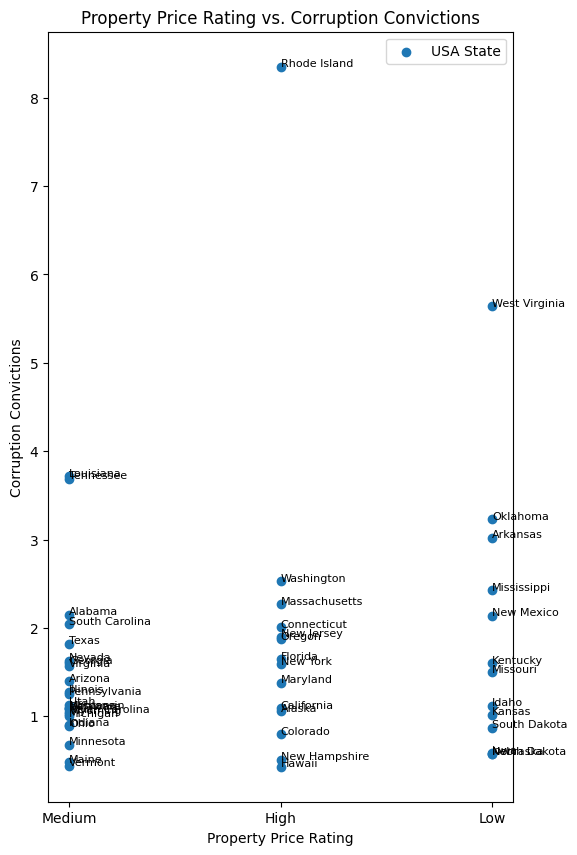

In [71]:
# Scatter Chart
x=df_join_corruption_groupproperty['rating']
y=df_join_corruption_groupproperty['convictions_per_capita']
n=df_join_corruption_groupproperty['state_usa']
fig, ax = plt.subplots(figsize=(6, 10))
ax.scatter(x, y)
for i, txt in enumerate(n):
    ax.annotate(txt, (x[i], y[i]), fontsize=8)
plt.title('Property Price Rating vs. Corruption Convictions')
plt.xlabel('Property Price Rating')
plt.ylabel('Corruption Convictions')
plt.legend(['USA State'], loc="upper right")

In [72]:
# Filter df_join_corruption_groupproperty where avg_price gt df_property_mean_avg_price
df_join_corruption_groupproperty_gt_avg = df_join_corruption_groupproperty[df_join_corruption_groupproperty['avg_price'] >= df_property_mean_avg_price]
df_join_corruption_groupproperty_gt_avg

,state_usa,convictions_per_capita,avg_price,rating
1,Alaska,1.06,2684.00,High
4,California,1.09,5832.50,High
5,Colorado,0.80,2987.25,High
6,Connecticut,2.01,3837.00,High
8,Florida,1.65,2763.50,High
10,Hawaii,0.43,5975.50,High
19,Maryland,1.38,3122.75,High
20,Massachusetts,2.27,4136.50,High
27,Nevada,1.63,2503.00,Medium
28,New Hampshire,0.51,3122.75,High


In [73]:
# Filter df_join_corruption_groupproperty where avg_price lt df_property_mean_avg_price
df_join_corruption_groupproperty_lt_avg = df_join_corruption_groupproperty[df_join_corruption_groupproperty['avg_price'] <= df_property_mean_avg_price]
df_join_corruption_groupproperty_lt_avg

,state_usa,convictions_per_capita,avg_price,rating
0,Alabama,2.15,1797.50,Medium
2,Arizona,1.40,2356.75,Medium
3,Arkansas,3.02,1499.25,Low
7,Delaware,1.08,2289.75,Medium
9,Georgia,1.60,2065.00,Medium
11,Idaho,1.12,1382.00,Low
12,Illinois,1.27,2056.50,Medium
13,Indiana,0.90,1704.75,Medium
14,Iowa,0.58,1442.25,Low
15,Kansas,1.02,1479.50,Low


**Q12. How does the average property price per square meter vary between states with different population densities, and what are the implications for business expansion?**

In [74]:
# Read CSV - property_prices
df_property_prices = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Refocus_Modules/FP_set1/property_prices.csv')

# Read CSV - population
df_population = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Refocus_Modules/FP_set1/population.csv')

In [75]:
# Head
display(df_property_prices.head())
display(df_population.head())

,state_usa,avg_price,min_price,max_price
0,Alabama,1797.50,1200.0,2500.0
1,Alaska,2684.00,2000.0,3500.0
2,Arizona,2356.75,1500.0,4000.0
3,Arkansas,1499.25,1000.0,2500.0
4,California,5832.50,3500.0,9000.0


,state_usa,estimate
0,Alabama,4903185
1,Alaska,731545
2,Arizona,7278717
3,Arkansas,3017804
4,California,39512223


In [76]:
# Merge - Inner Join - df_property_prices & df_population
df_join_propprices_popul = pd.merge(df_property_prices, df_population, on="state_usa", how='inner')
df_join_propprices_popul.head()

,state_usa,avg_price,min_price,max_price,estimate
0,Alabama,1797.50,1200.0,2500.0,4903185
1,Alaska,2684.00,2000.0,3500.0,731545
2,Arizona,2356.75,1500.0,4000.0,7278717
3,Arkansas,1499.25,1000.0,2500.0,3017804
4,California,5832.50,3500.0,9000.0,39512223


In [77]:
# Drop columns - min_price, max_price
df_join_propprices_popul2 = df_join_propprices_popul.drop(['min_price','max_price'], axis=1)
df_join_propprices_popul2.head()

,state_usa,avg_price,estimate
0,Alabama,1797.50,4903185
1,Alaska,2684.00,731545
2,Arizona,2356.75,7278717
3,Arkansas,1499.25,3017804
4,California,5832.50,39512223


In [78]:
# Correlation Matrix
df_join_propprices_popul2.corr()

<ipython-input-78-56676b71cb09>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_join_propprices_popul2.corr()


,avg_price,estimate
avg_price,1.000000,0.418059
estimate,0.418059,1.000000


<ipython-input-79-f0ac642615d1>:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df_join_propprices_popul2.corr(), annot=True, cmap="RdYlGn", vmin=-1, vmax=1)


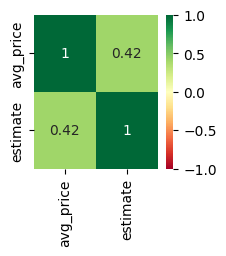

In [79]:
# Heatmap / df_join_propprices_popul2.corr()
plt.figure(figsize=(2,2))
sns.heatmap(df_join_propprices_popul2.corr(), annot=True, cmap="RdYlGn", vmin=-1, vmax=1)
plt.show();

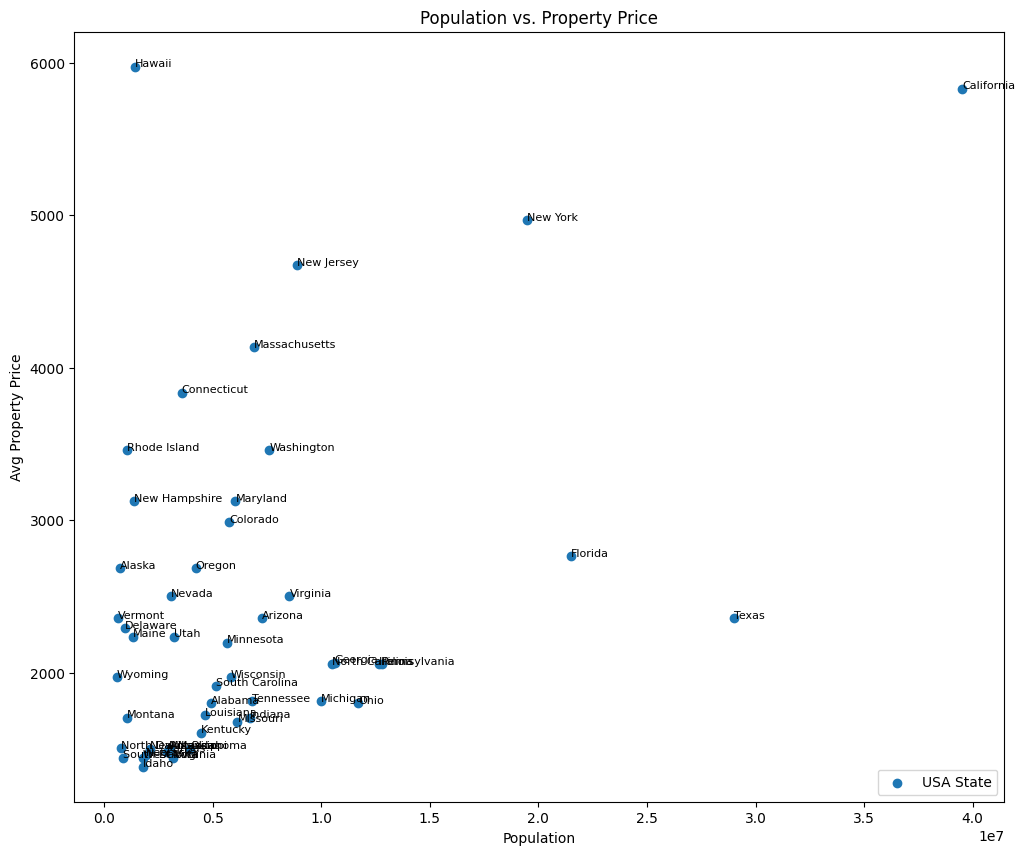

In [80]:
# Scatter Chart
x=df_join_propprices_popul2['estimate']
y=df_join_propprices_popul2['avg_price']
n=df_join_propprices_popul2['state_usa']
fig, ax = plt.subplots(figsize=(12, 10))
ax.scatter(x, y)
for i, txt in enumerate(n):
    ax.annotate(txt, (x[i], y[i]), fontsize=8)
plt.title('Population vs. Property Price')
plt.xlabel('Population')
plt.ylabel('Avg Property Price')
plt.legend(['USA State'], loc="lower right")

**Q13. How do a state's average income and population size affect the average spending on healthcare-related products and services per person?**

In [81]:
# Read CSV - state_income
df_stateincome = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Refocus_Modules/FP_set1/state_income.csv')

# Read CSV - population
df_population = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Refocus_Modules/FP_set1/population.csv')

In [82]:
# Head
display(df_stateincome.head())
display(df_population.head())

,state_usa,average_income,minimum_income,maximum_income
0,Alabama,51113,23999,96993
1,Alaska,76440,35219,134318
2,Arizona,62283,29466,113589
3,Arkansas,48829,23028,90052
4,California,80440,37698,149265


,state_usa,estimate
0,Alabama,4903185
1,Alaska,731545
2,Arizona,7278717
3,Arkansas,3017804
4,California,39512223


In [83]:
# Merge - Inner Join - df_stateincome & df_population
df_join_stateincome_population = pd.merge(df_stateincome, df_population, on="state_usa", how='inner')
df_join_stateincome_population.head()

,state_usa,average_income,minimum_income,maximum_income,estimate
0,Alabama,51113,23999,96993,4903185
1,Alaska,76440,35219,134318,731545
2,Arizona,62283,29466,113589,7278717
3,Arkansas,48829,23028,90052,3017804
4,California,80440,37698,149265,39512223


In [84]:
# Drop Columns - df_join_stateincome_population
df_join_stateincome_population2 = df_join_stateincome_population.drop(['minimum_income', 'maximum_income'], axis=1)
df_join_stateincome_population2.head()

,state_usa,average_income,estimate
0,Alabama,51113,4903185
1,Alaska,76440,731545
2,Arizona,62283,7278717
3,Arkansas,48829,3017804
4,California,80440,39512223


In [85]:
# Correlation Matrix
df_join_stateincome_population2.corr()

<ipython-input-85-3aac4cf1ea1c>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_join_stateincome_population2.corr()


,average_income,estimate
average_income,1.000000,0.233171
estimate,0.233171,1.000000


<ipython-input-86-558e0b4651c6>:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df_join_stateincome_population2.corr(), annot=True, cmap="RdYlGn", vmin=-1, vmax=1)


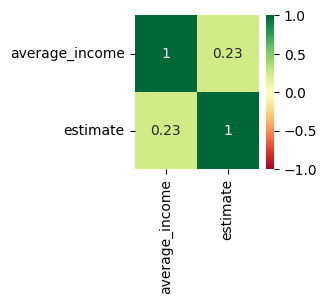

In [86]:
# Heatmap / df_join_stateincome_population2.corr()
plt.figure(figsize=(2,2))
sns.heatmap(df_join_stateincome_population2.corr(), annot=True, cmap="RdYlGn", vmin=-1, vmax=1)
plt.show();

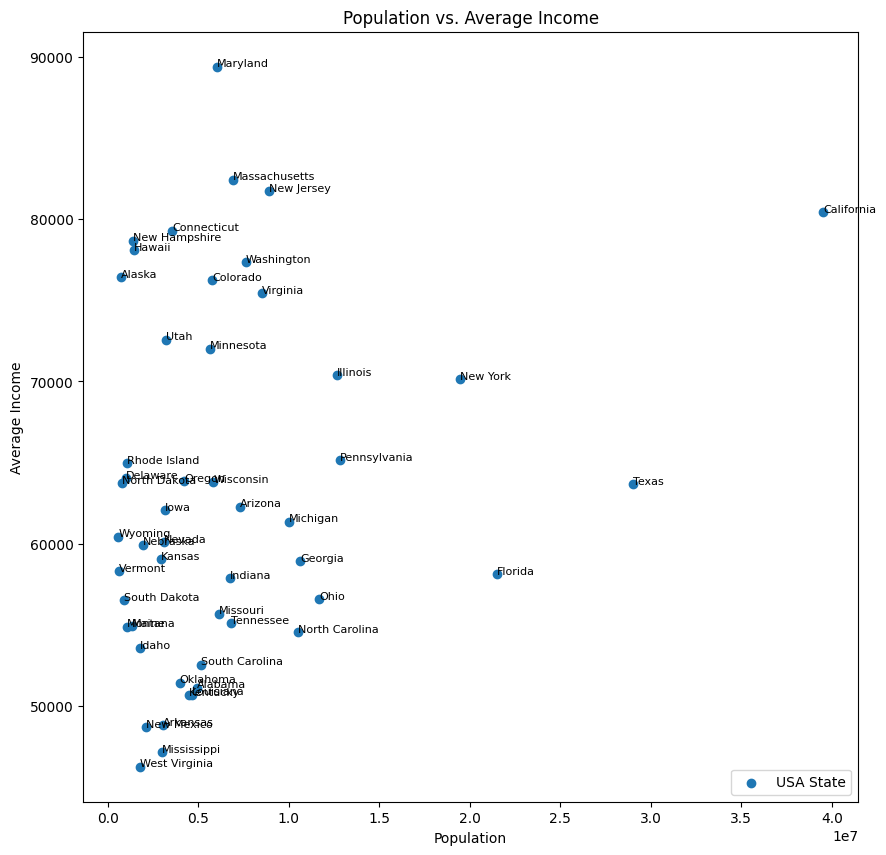

In [87]:
# Scatter Chart
x=df_join_stateincome_population2['estimate']
y=df_join_stateincome_population2['average_income']
n=df_join_stateincome_population2['state_usa']
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(x, y)
for i, txt in enumerate(n):
    ax.annotate(txt, (x[i], y[i]), fontsize=8)
plt.title('Population vs. Average Income')
plt.xlabel('Population')
plt.ylabel('Average Income')
plt.legend(['USA State'], loc="lower right")

**Q14. Is there a correlation between a state's level of corruption and its competitor companies' profits?**

In [88]:
# Read CSV - corruptions
df_corruptions = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Refocus_Modules/FP_set1/corruption_convictions_per_capita.csv')

# Read CSV - competitors
df_competitors = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Refocus_Modules/FP_set1/competitors.csv')

In [89]:
# Head
display(df_corruptions.head())
display(df_competitors.head())

,state_usa,convictions_per_capita
0,Alabama,2.15
1,Alaska,1.06
2,Arizona,1.40
3,Arkansas,3.02
4,California,1.09


,research_development_spent,administration,marketing_spent,state_usa,profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [90]:
# Group By
df_group_competitors = df_competitors.groupby('state_usa')['profit'].sum().reset_index()
df_group_competitors.head()

,state_usa,profit
0,Alabama,5692296.95
1,Alaska,9845632.95
2,Arizona,2942282.99
3,Arkansas,1487917.98
4,California,10754524.00


In [91]:
# Merge - Inner Join - df_corruptions & df_group_competitors
df_join_corruption_competitors = pd.merge(df_corruptions, df_group_competitors, on="state_usa", how='inner')
df_join_corruption_competitors.head()

,state_usa,convictions_per_capita,profit
0,Alabama,2.15,5692296.95
1,Alaska,1.06,9845632.95
2,Arizona,1.40,2942282.99
3,Arkansas,3.02,1487917.98
4,California,1.09,10754524.00


In [92]:
# Correlation Matrix
df_join_corruption_competitors.corr()

<ipython-input-92-884de8bc1efd>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_join_corruption_competitors.corr()


,convictions_per_capita,profit
convictions_per_capita,1.000000,0.149096
profit,0.149096,1.000000


<ipython-input-93-9bb5d39fb930>:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df_join_corruption_competitors.corr(), annot=True, cmap="RdYlGn", vmin=-1, vmax=1)


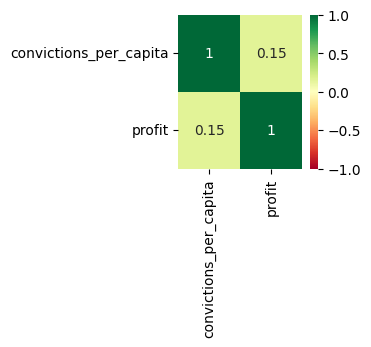

In [93]:
# Heatmap / df_join_corruption_competitors.corr()
plt.figure(figsize=(2,2))
sns.heatmap(df_join_corruption_competitors.corr(), annot=True, cmap="RdYlGn", vmin=-1, vmax=1)
plt.show();

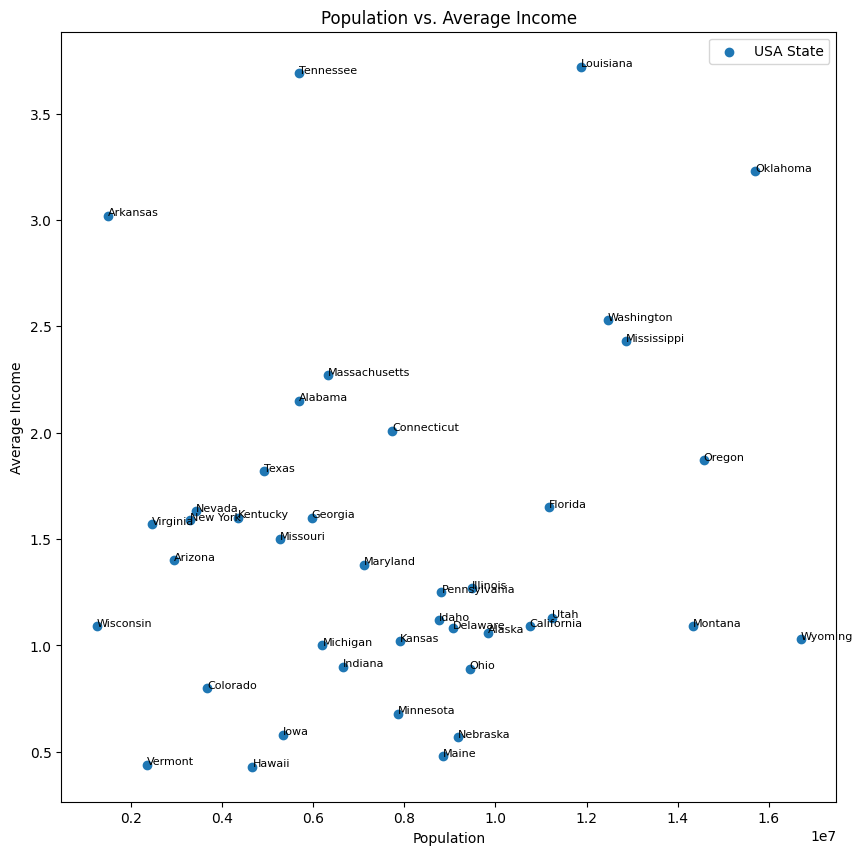

In [94]:
# Scatter Chart
x=df_join_corruption_competitors['profit']
y=df_join_corruption_competitors['convictions_per_capita']
n=df_join_corruption_competitors['state_usa']
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(x, y)
for i, txt in enumerate(n):
    ax.annotate(txt, (x[i], y[i]), fontsize=8)
plt.title('Population vs. Average Income')
plt.xlabel('Population')
plt.ylabel('Average Income')
plt.legend(['USA State'], loc="upper right")

**Q15. How does the average spending on healthcare-related products and services per person vary between states with different levels of corruption?**

In [95]:
# Read CSV - corruption
df_corruption = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Refocus_Modules/FP_set1/corruption_convictions_per_capita.csv')

# Read CSV - health_spending
df_health_spending = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Refocus_Modules/FP_set1/health_spending.csv')

In [96]:
# Head
display(df_corruption.head())
display(df_health_spending.head())

,state_usa,convictions_per_capita
0,Alabama,2.15
1,Alaska,1.06
2,Arizona,1.40
3,Arkansas,3.02
4,California,1.09


,state_usa,avg_spending,min_spending,max_spending
0,Alabama,200.50,50.0,500.0
1,Alaska,300.25,100.0,750.0
2,Arizona,150.00,25.0,300.0
3,Arkansas,175.00,75.0,400.0
4,California,250.75,50.0,600.0


In [97]:
# Merge - Inner Join - df_corruption & df_health_spending
df_join_corruption_healthspend = pd.merge(df_corruption, df_health_spending, on="state_usa", how='inner')
df_join_corruption_healthspend.head()

,state_usa,convictions_per_capita,avg_spending,min_spending,max_spending
0,Alabama,2.15,200.50,50.0,500.0
1,Alaska,1.06,300.25,100.0,750.0
2,Arizona,1.40,150.00,25.0,300.0
3,Arkansas,3.02,175.00,75.0,400.0
4,California,1.09,250.75,50.0,600.0


In [98]:
# Drop Columns - df_join_corruption_healthspend
df_join_corruption_healthspend2 = df_join_corruption_healthspend.drop(['min_spending', 'max_spending'], axis=1)
df_join_corruption_healthspend2.head()

,state_usa,convictions_per_capita,avg_spending
0,Alabama,2.15,200.50
1,Alaska,1.06,300.25
2,Arizona,1.40,150.00
3,Arkansas,3.02,175.00
4,California,1.09,250.75


In [99]:
# Correlation Matrix
df_join_corruption_healthspend2.corr()

<ipython-input-99-6149fac996fd>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_join_corruption_healthspend2.corr()


,convictions_per_capita,avg_spending
convictions_per_capita,1.000000,0.173831
avg_spending,0.173831,1.000000


<ipython-input-100-801a18b74d64>:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df_join_corruption_healthspend2.corr(), annot=True, cmap="RdYlGn", vmin=-1, vmax=1)


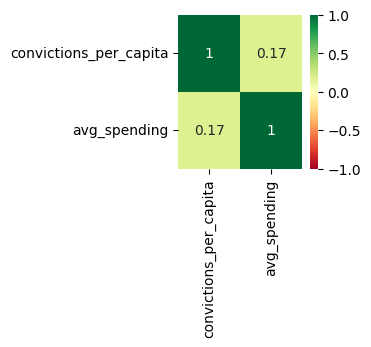

In [100]:
# Heatmap / df_join_corruption_healthspend2.corr()
plt.figure(figsize=(2,2))
sns.heatmap(df_join_corruption_healthspend2.corr(), annot=True, cmap="RdYlGn", vmin=-1, vmax=1)
plt.show();

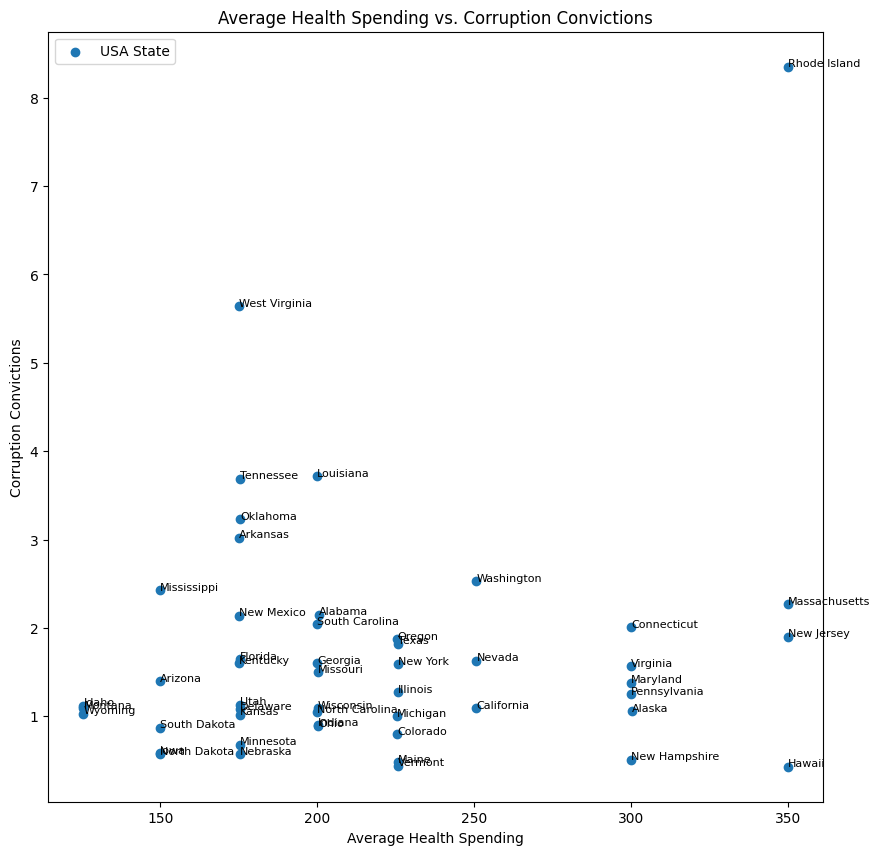

In [101]:
# Scatter Chart
x=df_join_corruption_healthspend2['avg_spending']
y=df_join_corruption_healthspend2['convictions_per_capita']
n=df_join_corruption_healthspend2['state_usa']
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(x, y)
for i, txt in enumerate(n):
    ax.annotate(txt, (x[i], y[i]), fontsize=8)
plt.title('Average Health Spending vs. Corruption Convictions')
plt.xlabel('Average Health Spending')
plt.ylabel('Corruption Convictions')
plt.legend(['USA State'], loc="upper left")